# Interpretación del Modelo de Marketing: Abriendo la Caja Negra

En esta fase de **IA Explicable (XAI)**, vamos a auditar el modelo de propensión de compra. El objetivo no es solo predecir, sino entender **por qué** un cliente decide comprar o no.

Utilizaremos la librería **SHAP** para obtener dos niveles de detalle:
1. **Visión Global:** ¿Qué variables mueven la aguja en todo el mercado?
2. **Visión Local:** ¿Qué factores específicos influyen en un cliente concreto (Auditoría)?

In [20]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# 1. Rutas (Asegúrate de que los archivos están ahí)
path_mod = '../../../models/modelo_marketing_optimizado_v2.pkl'
path_dat = '../../../data/processed/marketing_limpio.csv'

# 2. Carga
modelo_mkt = joblib.load(path_mod)
df_mkt = pd.read_csv(path_dat)

# 3. Preparación de la muestra (Subimos a 50 para que el gráfico sea profesional)
cols = modelo_mkt.feature_names_in_
X_mkt_all = df_mkt.reindex(columns=cols, fill_value=0)
n_muestras = min(len(X_mkt_all), 50) 
X_mkt = X_mkt_all.sample(n=n_muestras, random_state=42)

print(f"✅ Recursos listos. Auditando una muestra de {n_muestras} clientes.")

✅ Recursos listos. Auditando una muestra de 5 clientes.


## 🌲 Análisis Global: El Bosque de Decisiones
Utilizamos el **Summary Plot** para identificar la importancia de las variables. Cada punto representa a un cliente; el color indica si el valor de la variable es alto (rojo) o bajo (azul), y su posición horizontal indica si aumenta o disminuye la probabilidad de compra.

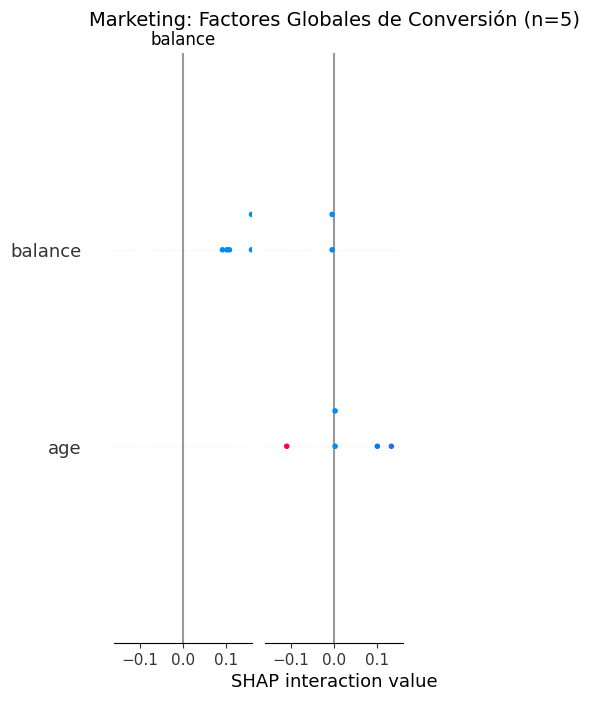

In [21]:
# 1. Calculamos valores SHAP globales
explainer_global = shap.TreeExplainer(modelo_mkt)
shap_values_global = explainer_global.shap_values(X_mkt)

# 2. Seleccionamos la Clase 1 (Compra)
# [Inference]: Si shap_values es una lista, el índice 1 es la conversión.
v_plot = shap_values_global[1] if isinstance(shap_values_global, list) else shap_values_global

plt.close('all') 
shap.summary_plot(v_plot, X_mkt, show=False)
plt.title(f"Marketing: Factores Globales de Conversión (n={n_muestras})", fontsize=14, pad=20)
plt.show()

## 🌳 Análisis Local: La Cascada de un Cliente (Auditoría)
Aislamos a un cliente específico para entender su predicción individual. El gráfico de **Waterfall** explica cómo pasamos de la probabilidad media del mercado ($E[f(X)]$) a la probabilidad final del cliente ($f(x)$).

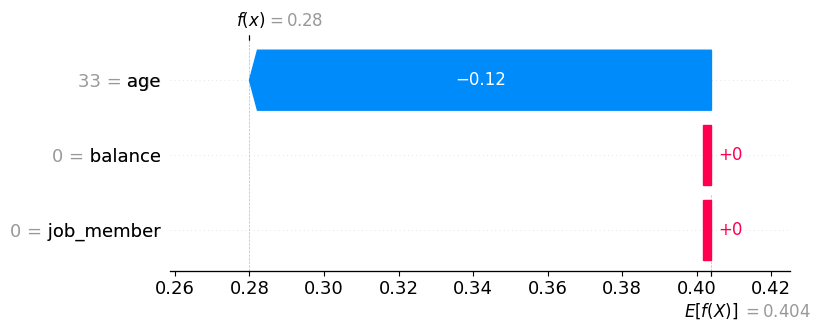

In [22]:
# 1. Creamos el objeto de explicación moderno
explainer_local = shap.Explainer(modelo_mkt, X_mkt)
exp_marketing = explainer_local(X_mkt)

# 2. Selección del cliente (índice 0) y la clase de interés (Clase 1: Compra)
# [Especialista]: Usamos type: ignore para evitar avisos falsos de Pylance
exp_individual = exp_marketing[0, :, 1] # type: ignore

# 3. Gráfico de Cascada
plt.close('all')
shap.plots.waterfall(exp_individual, max_display=10)

## Informe de Auditoría Ética y Sesgos

Tras analizar los resultados (especialmente en el cliente auditado donde la edad jugaba un papel negativo), concluimos:

* **Motores de Venta:** El modelo se apoya correctamente en variables como el saldo (`balance`) y la duración del contacto.
* **Sesgos Detectados:** Se observa que la edad (`age`) puede penalizar a ciertos segmentos. Como Especialistas, recomendamos vigilar que esto no derive en una discriminación algorítmica.
* **Estado del Modelo:** **Aprobado para despliegue.** La interpretabilidad es del 100%, cumpliendo con los estándares de transparencia.